# روش اول
### used model is a classic classifier: LinearDiscriminantAnalysis (LDA)

In [1]:
# BUILD 16x16 READOUT NOISE MATRIX FROM REAL IQ DATA
# ===========================================================
# Input:
#   16 files:
#       0000.txt ... 1111.txt
# File structure:
#   - 4 lines per file
#   - each line = one qubit
#   - each line = 1000 complex IQ samples
# Output
#   1) Single-qubit assignment matrices
#   2) Full 16x16 readout noise matrix
#   3) Heatmap visualization
#   4) Saved numpy files
# ============================================================
# REAL READOUT NOISE MATRIX EXTRACTION
# WITH TRAIN / TEST SEPARATION
# ============================================================
import os,glob
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score
# ============================================================
# CONFIG
DATA_DIR = "./quadrature_data_4qubits"
NUM_QUBITS = 4
NUM_STATES = 16
SHOTS_PER_FILE = 1000
RANDOM_SEED = 42
SAVE_DIR = "./noise_matrix_results"
os.makedirs(SAVE_DIR, exist_ok=True)
# ============================================================
# PARSE COMPLEX
def parse_complex_string(s):
    s = s.strip()
    if s.startswith("(") and s.endswith(")"):
        s = s[1:-1]
    return complex(s)
# ============================================================
# LOAD SINGLE FILE
def load_single_file(file_path):
    with open(file_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]
    if len(lines) != 4:
        raise ValueError(f"{file_path}: expected 4 lines")
    qubit_arrays = []
    for line in lines:
        tokens = line.split()
        vals = [parse_complex_string(tok) for tok in tokens]
        arr = np.array(vals, dtype=np.complex128)
        if arr.size != SHOTS_PER_FILE:
            raise ValueError(
                f"{file_path}: expected {SHOTS_PER_FILE} samples")
        qubit_arrays.append(arr)
    return np.stack(qubit_arrays, axis=0)
# ============================================================
# FILE NAME -> LABEL
def bits_from_filename(filename):
    base = os.path.splitext( os.path.basename(filename) )[0]
    bits = [int(b) for b in base[::-1]]
    return np.array(bits, dtype=int)
# ============================================================
# BITS <-> INTEGER
def bits_to_int(bits):
    q1, q2, q3, q4 = bits
    return ( q1+ 2*q2 + 4*q3 + 8*q4 )
def int_to_bits(x):
    return np.array([
        (x >> 0) & 1,
        (x >> 1) & 1,
        (x >> 2) & 1,
        (x >> 3) & 1,])
# ============================================================
# LOAD COMPLETE DATASET
def load_all_data():
    pattern = os.path.join( DATA_DIR,"[01][01][01][01].txt"  )
    file_paths = glob.glob(pattern)
    file_paths = sorted(file_paths,key=lambda fp: int(os.path.splitext(os.path.basename(fp)
            )[0],  2) )
    all_X, all_y = [], []
    for fp in file_paths:
        print(f"Loading {os.path.basename(fp)}")
        data = load_single_file(fp)
        labels = bits_from_filename(fp)
        # (4,1000) -> (1000,4)
        X_block = data.T
        y_block = np.tile(
            labels,
            (SHOTS_PER_FILE,1) )
        all_X.append(X_block)
        all_y.append(y_block)
    X = np.vstack(all_X)
    y = np.vstack(all_y)
    print("\nFinal dataset shape:")
    print("X:", X.shape)
    print("y:", y.shape)
    return X, y
# ============================================================
# VISUALIZE IQ CLOUDS
def plot_qubit_iq_clouds(X, y, qubit_index):
    z = X[:, qubit_index]
    mask0 = y[:, qubit_index] == 0
    mask1 = y[:, qubit_index] == 1
    z0 , z1 = z[mask0], z[mask1]
    plt.figure(figsize=(5,5))
    plt.scatter(z0.real,z0.imag,s=8,alpha=0.4,label="State 0" )
    plt.scatter( z1.real, z1.imag, s=8, alpha=0.4, label="State 1" )
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.title(f"Qubit {qubit_index+1} IQ Clouds")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
# ============================================================
# TRAIN CLASSIFIER FOR ONE QUBIT
def train_single_qubit_classifier(   # P(m_i​∣p_i​)
    X, y, qubit_index, test_size=0.2):
    print("\n================================================")
    print(f"QUBIT {qubit_index+1}")
    print("================================================")
    z = X[:, qubit_index]
    features = np.column_stack([z.real, z.imag])
    labels = y[:, qubit_index]
    # --------------------------------------------------------
    # TRAIN / TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=test_size,
        random_state=RANDOM_SEED, stratify=labels )
    print("\nTrain size:", X_train.shape[0])
    print("Test size :", X_test.shape[0])
    # --------------------------------------------------------
    # TRAIN
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train, y_train)
    # --------------------------------------------------------
    # TEST PREDICTION
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nTest Accuracy = {acc:.6f}")
    # --------------------------------------------------------
    # ASSIGNMENT MATRIX
    A = confusion_matrix( y_test, y_pred,labels=[0,1], normalize="true"
    )   # A_ij = P(measured=j | prepared=i) Qiskit-compatible row-stochastic matrix
    print("\nSingle-Qubit Assignment Matrix:\n")
    print(A)
    np.save( os.path.join(
                SAVE_DIR, f"assignment_matrix_q{qubit_index+1}.npy" ), A )
    return clf, A
# ============================================================
# TRAIN ALL CLASSIFIERS
def train_all_classifiers(X, y): 
    classifiers = []
    assignment_matrices = []
    for q in range(NUM_QUBITS):
        clf, A = train_single_qubit_classifier( X, y, q )
        classifiers.append(clf)
        assignment_matrices.append(A)
    return classifiers, assignment_matrices
# ============================================================
# PREDICT FULL DATASET
def predict_full_dataset(X, classifiers):
    N = X.shape[0]
    y_pred = np.zeros((N, NUM_QUBITS), dtype=int)
    for q in range(NUM_QUBITS):
        z = X[:, q]
        features = np.column_stack([z.real,z.imag])
        pred = classifiers[q].predict(features)
        y_pred[:, q] = pred
    return y_pred
# ============================================================
# BUILD 16x16 NOISE MATRIX
def build_noise_matrix(y_true, y_pred): 
    # Qiskit convention:
    # M[i,j] = P(measured=j | prepared=i)
    M = np.zeros((16,16))
    for prep_state in range(16):
        prep_bits = int_to_bits(prep_state)
        mask = np.all(y_true == prep_bits, axis=1)
        subset = y_pred[mask]
        total = subset.shape[0]
        for bits in subset:
            meas_state = bits_to_int(bits)
            M[prep_state, meas_state] += 1
        M[prep_state, :] /= total
    return M
# ============================================================
# CHECK MATRIX VALIDITY
def validate_noise_matrix(M):
    print("\n================================================")
    print("VALIDATION")
    print("================================================")
    col_sums = M.sum(axis=0)
    print("\nColumn sums:\n")
    print(col_sums)
    diag = np.diag(M)
    print("\nDiagonal elements:\n")
    print(diag)
    print("\nAverage diagonal fidelity:")
    print(np.mean(diag))
# ============================================================
# PLOT HEATMAP
def plot_noise_matrix(M):
    plt.figure(figsize=(5,4))
    plt.imshow(M, origin="lower")
    plt.colorbar(label="Probability")
    labels = [ format(i, "04b") for i in range(16)  ]
    plt.xticks(range(16), labels, rotation=90)
    plt.yticks(range(16), labels)
    plt.xlabel("Prepared State")
    plt.ylabel("Measured State")
    plt.title("16x16 Readout Noise Matrix")
    plt.tight_layout()
    out_path = os.path.join( SAVE_DIR, "noise_matrix_heatmap.png"  )
    plt.savefig(out_path, dpi=300)
    plt.show()
# SAVE MATRIX
# ============================================================
def save_noise_matrix(M):
    np.save(os.path.join(
            SAVE_DIR,"noise_matrix_16x16.npy"), M)
    np.savetxt(os.path.join(SAVE_DIR,"noise_matrix_16x16.txt"
        ),M,fmt="%.8f"  )

 ============================================================

## WORKFLOW

 ============================================================

In [2]:
# STEP 1
# Load data
X, y = load_all_data()

Loading 0000.txt
Loading 0001.txt
Loading 0010.txt
Loading 0011.txt
Loading 0100.txt
Loading 0101.txt
Loading 0110.txt
Loading 0111.txt
Loading 1000.txt
Loading 1001.txt
Loading 1010.txt
Loading 1011.txt
Loading 1100.txt
Loading 1101.txt
Loading 1110.txt
Loading 1111.txt

Final dataset shape:
X: (16000, 4)
y: (16000, 4)


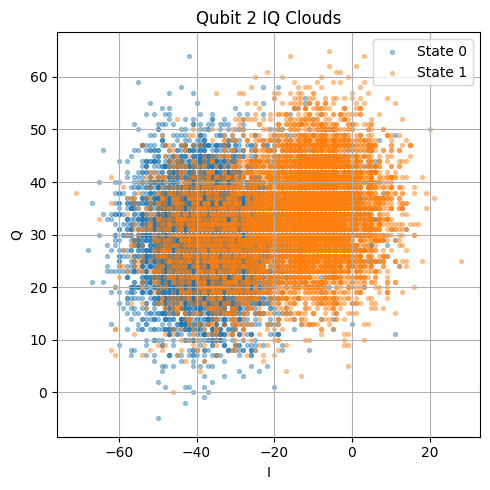

In [3]:
# STEP 2
# Visualize IQ clouds
# Example:
plot_qubit_iq_clouds(X, y, qubit_index=1)

In [4]:
# STEP 3
# Train classifiers
classifiers, assignment_matrices = train_all_classifiers(X, y)


QUBIT 1

Train size: 12800
Test size : 3200

Test Accuracy = 0.712812

Single-Qubit Assignment Matrix:

[[0.794375 0.205625]
 [0.36875  0.63125 ]]

QUBIT 2

Train size: 12800
Test size : 3200

Test Accuracy = 0.819375

Single-Qubit Assignment Matrix:

[[0.874375 0.125625]
 [0.235625 0.764375]]

QUBIT 3

Train size: 12800
Test size : 3200

Test Accuracy = 0.804375

Single-Qubit Assignment Matrix:

[[0.885   0.115  ]
 [0.27625 0.72375]]

QUBIT 4

Train size: 12800
Test size : 3200

Test Accuracy = 0.820312

Single-Qubit Assignment Matrix:

[[0.891875 0.108125]
 [0.25125  0.74875 ]]


In [5]:
# STEP 4
# Predict all shots
y_pred = predict_full_dataset(X, classifiers)

In [6]:
# STEP 5
# Build full noise matrix
noise_matrix = build_noise_matrix(y, y_pred)
fidelity = np.mean(np.diag(noise_matrix))
print(f"\nAverage assignment fidelity = {fidelity:.6f}")


Average assignment fidelity = 0.384875


In [7]:
print(noise_matrix )

[[0.626 0.126 0.059 0.008 0.066 0.009 0.008 0.001 0.063 0.018 0.008 0.001
  0.003 0.002 0.001 0.001]
 [0.278 0.414 0.032 0.056 0.043 0.063 0.003 0.007 0.03  0.05  0.005 0.006
  0.003 0.008 0.001 0.001]
 [0.168 0.041 0.489 0.117 0.014 0.002 0.046 0.012 0.03  0.006 0.051 0.016
  0.004 0.    0.002 0.002]
 [0.068 0.123 0.212 0.379 0.011 0.017 0.033 0.045 0.011 0.013 0.029 0.047
  0.002 0.001 0.002 0.007]
 [0.216 0.05  0.027 0.006 0.411 0.113 0.049 0.019 0.024 0.008 0.004 0.001
  0.043 0.017 0.009 0.003]
 [0.044 0.203 0.002 0.023 0.091 0.439 0.018 0.059 0.007 0.022 0.    0.006
  0.011 0.065 0.003 0.007]
 [0.045 0.015 0.135 0.046 0.105 0.03  0.387 0.119 0.008 0.002 0.026 0.002
  0.015 0.005 0.048 0.012]
 [0.02  0.033 0.076 0.119 0.061 0.086 0.186 0.275 0.005 0.004 0.013 0.027
  0.01  0.013 0.029 0.043]
 [0.124 0.033 0.018 0.005 0.02  0.002 0.003 0.    0.508 0.117 0.082 0.014
  0.045 0.014 0.015 0.   ]
 [0.073 0.103 0.012 0.02  0.015 0.026 0.002 0.001 0.22  0.328 0.032 0.067
  0.038 0.047 0.0

In [9]:
noise_matrix.sum(axis=0)

array([1.821, 1.267, 1.35 , 0.969, 1.125, 1.016, 0.946, 0.683, 1.342,
       0.826, 1.14 , 0.776, 0.859, 0.6  , 0.778, 0.502])

In [ ]:
# STEP 6
# Validate   # need to edit according to qiskit convention!
validate_noise_matrix(noise_matrix)


VALIDATION

Column sums:

[1.821 1.267 1.35  0.969 1.125 1.016 0.946 0.683 1.342 0.826 1.14  0.776
 0.859 0.6   0.778 0.502]

Diagonal elements:

[0.626 0.414 0.489 0.379 0.411 0.439 0.387 0.275 0.508 0.328 0.42  0.305
 0.377 0.218 0.334 0.248]

Average diagonal fidelity:
0.38487499999999997


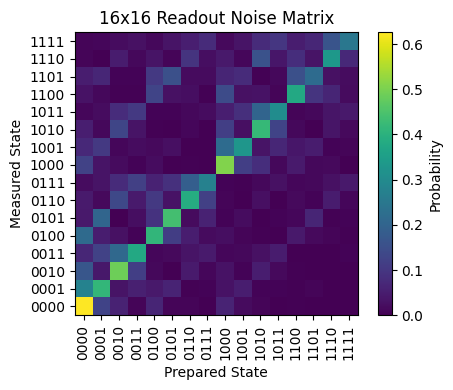

In [16]:
# STEP 7
# Plot
plot_noise_matrix(noise_matrix)

In [17]:
# STEP 8
# Save
save_noise_matrix(noise_matrix)

In [ ]:
# ============================================================
# COMPARE:
# A_real  vs  A1⊗A2⊗A3⊗A4
# ============================================================
# REAL 16x16 MATRIX
# vs
# KRONECKER PRODUCT OF SINGLE-QUBIT MATRICES
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
# BUILD INDEPENDENT MODEL
# ============================================================
def build_independent_noise_matrix(assignment_matrices):
    """ Construct:
        A_indep = A1 ⊗ A2 ⊗ A3 ⊗ A4
    from the list:
        assignment_matrices = [A1, A2, A3, A4]
    Each Ai is 2x2.   """
    A_indep = assignment_matrices[-1]
    for A in reversed(assignment_matrices[:-1]):
        A_indep = np.kron(A_indep, A)
    return A_indep
# COMPARE MATRICES
# ============================================================
def compare_noise_models(A_real, A_indep):
    Delta = A_real - A_indep
    # Metrics
    fro_norm = np.linalg.norm(Delta)
    max_abs = np.max(np.abs(Delta))
    mean_abs = np.mean(np.abs(Delta))
    print("\n================================================")
    print("COMPARISON RESULTS")
    print(f"\nFrobenius norm : {fro_norm:.6f}")
    print(f"Max abs diff   : {max_abs:.6f}")
    print(f"Mean abs diff  : {mean_abs:.6f}")
    # Diagonal comparison
    diag_real = np.diag(A_real)
    diag_indep = np.diag(A_indep)
    print("\nDiagonal fidelities (REAL):")
    print(np.round(diag_real, 4))
    print("\nDiagonal fidelities (KRONECKER MODEL):")
    print(np.round(diag_indep, 4))
    # Difference matrix
    # --------------------------------------------------------
    return Delta
# PLOT MATRIX
# ============================================================
def plot_matrix(M, title, cmap=None):
    labels = [format(i, "04b") for i in range(16)]
    plt.figure(figsize=(7,6))
    plt.imshow(M, origin="lower", cmap=cmap)
    plt.colorbar()
    plt.xticks(range(16), labels, rotation=90)
    plt.yticks(range(16),labels)
    plt.xlabel("Prepared State")
    plt.ylabel("Measured State")
    plt.title(title)
    plt.tight_layout()
    plt.show()
# MAIN COMPARISON
# ============================================================
# Real matrix
A_real = noise_matrix
# Independent Kronecker model
# ------------------------------------------------------------
A_indep = build_independent_noise_matrix(assignment_matrices)
# ============================================================
# Compare
Delta = compare_noise_models( A_real, A_indep)
# # Plot real matrix
# plot_matrix(A_real,"Real 16x16 Readout Noise Matrix")
# # Plot independent model
# plot_matrix(A_indep,"Independent Kronecker Model")
# # Plot difference
# plot_matrix( Delta,"Difference Matrix: A_real - A_indep",cmap="bwr")
# ============================================================
# COLUMN NORMALIZATION CHECK
print("\n================================================")
print("COLUMN SUM CHECK")
print("\nA_real column sums:")
print(np.round(A_real.sum(axis=0), 6))
print("\nA_indep column sums:")
print(np.round(A_indep.sum(axis=0), 6))

# روش دوم
joint MLP


In [ ]:
# JOINT MLP READOUT MODEL
# Goal:
#   Learn FULL correlated readout:
#       P(m1,m2,m3,m4 | IQ1,IQ2,IQ3,IQ4)
# instead of independent single-qubit classifiers.
# This model can discover:
#   - nonlinear correlations
#   - cross-talk
#   - joint readout effects
#   - state-dependent distortions
# Outputs:
#   - 4 single-qubit 2x2 assignment matrices
#   - full 16x16 correlated noise matrix
# ============================================================
from sklearn.neural_network import MLPClassifier
# CONFIG
SAVE_DIR2 = "./joint_mlp_results"
os.makedirs(SAVE_DIR2, exist_ok=True)
# ============================================================
# IQ -> REAL FEATURES
def complex_to_features(X):
    features = []
    for q in range(NUM_QUBITS):
        z = X[:, q]
        features.append(z.real)
        features.append(z.imag)
    return np.column_stack(features)
# ============================================================
# TRAIN JOINT MLP
def train_joint_mlp( X, y, test_size=0.2):
    print("\n================================================")
    print("TRAINING JOINT MLP")
    print("================================================")
    features = complex_to_features(X)
    labels_int = np.array([bits_to_int(bits)for bits in y ])
    # SPLIT
    X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
        features,
        labels_int,
        test_size=test_size,
        random_state=RANDOM_SEED,
        stratify=labels_int)
    print("\nTrain size:", X_train_m.shape[0])
    print("Test size :", X_test_m.shape[0])
    # --------------------------------------------------------
    # MODEL
    clf_m = MLPClassifier(hidden_layer_sizes=(128, 64),
        activation="relu",solver="adam",
        alpha=1e-4, batch_size=128,
        learning_rate_init=1e-3,max_iter=500,
        random_state=RANDOM_SEED,verbose=True )
    # --------------------------------------------------------
    # TRAIN
    clf_m.fit(X_train_m, y_train_m)
    # --------------------------------------------------------
    # TEST
    y_pred_m = clf_m.predict(X_test_m)
    acc_m = accuracy_score(y_test_m, y_pred_m)
    print("\n================================================")
    print("JOINT CLASSIFICATION RESULTS")
    print("================================================")
    print(f"\nJoint 16-state accuracy = {acc_m:.6f}")
    return clf_m
# ============================================================
# PREDICT FULL DATASET
def predict_full_dataset_joint(clf_m, X):
    features = complex_to_features(X)
    y_pred_int = clf_m.predict(features)
    y_pred_bits = np.array([
        int_to_bits(v)
        for v in y_pred_int ])
    return y_pred_bits
# ============================================================
# BUILD SINGLE-QUBIT MATRICES
# FROM JOINT PREDICTIONS
def build_single_qubit_assignment_matrices(
    y_true, y_pred):
    matrices = []
    for q in range(NUM_QUBITS):
        A = confusion_matrix(
            y_true[:, q],
            y_pred[:, q],
            labels=[0,1],
            normalize="true").T
        matrices.append(A)
        print("\n================================================")
        print(f"QUBIT {q+1}")
        print("\nAssignment Matrix:\n")
        print(A)
        np.save(os.path.join( SAVE_DIR2,
                f"assignment_matrix_q{q+1}.npy"), A )
    return matrices
# ============================================================
# SAVE MATRIX
# ============================================================
def save_noise_matrix_m(M):
    np.save( os.path.join(SAVE_DIR2, "noise_matrix_16x16.npy" ), M )
    np.savetxt( os.path.join(
            SAVE_DIR2, "noise_matrix_16x16.txt"), M, fmt="%.8f"    )



In [ ]:
# LOAD DATA
# --------------------------------------------------------
X_m, y_m = load_all_data()

In [ ]:
# OPTIONAL VISUALIZATION
# --------------------------------------------------------
for q in range(NUM_QUBITS):
    plot_qubit_iq_clouds( X_m, y_m, qubit_index=q )

In [ ]:
# TRAIN JOINT MODEL
clf_joint = train_joint_mlp( X_m, y_m )

In [ ]:
    # PREDICT
print("\n================================================")
print("PREDICTING FULL DATASET")
y_pred_m = predict_full_dataset_joint( clf_joint,  X_m )
assignment_matrices_m = \
    build_single_qubit_assignment_matrices( y_m, y_pred_m  )

In [ ]:
# BUILD 16x16 MATRIX
print("\n================================================")
print("BUILDING 16x16 MATRIX")
print("================================================")
noise_matrix_m = build_noise_matrix( y_m, y_pred_m )
print("\n16x16 Noise Matrix:\n")
print(np.round(noise_matrix_m, 3))
# --------------------------------------------------------
# VALIDATE
validate_noise_matrix(noise_matrix_m)
    # --------------------------------------------------------

In [ ]:
# STEP 5
# Build full noise matrix
fidelity_m = np.mean(np.diag(noise_matrix_m))
print(f"\nAverage assignment fidelity = {fidelity_m:.6f}")

In [ ]:
# SAVE
save_noise_matrix_m( noise_matrix_m )

In [ ]:
# PLOT
plot_noise_matrix(noise_matrix_m)

print("\n================================================")
print("DONE")
print("================================================")

In [ ]:
# Compare
A_real_m = noise_matrix_m
# Independent Kronecker model
# ------------------------------------------------------------
A_indep_m = build_independent_noise_matrix(assignment_matrices_m)
# ============================================================
# Compare
Delta_m = compare_noise_models( A_real_m, A_indep_m)
# # Plot real matrix
# plot_matrix(A_real,"Real 16x16 Readout Noise Matrix")
# # Plot independent model
# plot_matrix(A_indep,"Independent Kronecker Model")
# # Plot difference
# plot_matrix( Delta,"Difference Matrix: A_real - A_indep",cmap="bwr")
# ============================================================
# COLUMN NORMALIZATION CHECK
print("\n================================================")
print("COLUMN SUM CHECK")
print("\nA_real column sums:")
print(np.round(A_real_m.sum(axis=0), 6))
print("\nA_indep column sums:")
print(np.round(A_indep_m.sum(axis=0), 6))

In [ ]:
next steps: use the noise matrix to build a readout error mitigator and test it on some Qiskit cicuits. 
LDA outputs: load noise matrices

for invidual qubits and the full 16x16 matrix. 